In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data= pd.read_csv('multiple_linear_regression_dataset.csv')
data

,age,experience,Education level,income
0,25,1,2,30450
1,30,3,3,35670
2,47,2,2,31580
3,32,5,4,40130
4,43,10,2,47830
5,51,7,2,41630
6,28,5,3,41340
7,33,4,3,37650
8,37,5,2,40250
9,39,8,4,45150


In [3]:
path = "multiple_linear_regression_dataset.csv"
df = pd.read_csv(path,header=None)
print(data.nunique())

age                16
experience         12
Education level     3
income             20
dtype: int64


In [4]:
df = df.drop(df.columns[2], axis=0)
df

,0,1,2,3
0,age,experience,Education level,income
1,25,1,2,30450
3,47,2,2,31580
4,32,5,4,40130
5,43,10,2,47830
6,51,7,2,41630
7,28,5,3,41340
8,33,4,3,37650
9,37,5,2,40250
10,39,8,4,45150


In [5]:
import numpy as np 
data_np = data.to_numpy()
data_np

array([[   25,     1,     2, 30450],
       [   30,     3,     3, 35670],
       [   47,     2,     2, 31580],
       [   32,     5,     4, 40130],
       [   43,    10,     2, 47830],
       [   51,     7,     2, 41630],
       [   28,     5,     3, 41340],
       [   33,     4,     3, 37650],
       [   37,     5,     2, 40250],
       [   39,     8,     4, 45150],
       [   29,     1,     4, 27840],
       [   47,     9,     2, 46110],
       [   54,     5,     2, 36720],
       [   51,     4,     3, 34800],
       [   44,    12,     3, 51300],
       [   41,     6,     3, 38900],
       [   58,    17,     4, 63600],
       [   23,     1,     2, 30870],
       [   44,     9,     2, 44190],
       [   37,    10,     4, 48700],
       [   25,     1,     2, 30450],
       [   39,     8,     4, 45150],
       [   58,    17,     4, 63600],
       [   51,     7,     2, 41630]], dtype=int64)

In [6]:
X= data_np[:, [0, 1]]
y = data_np[:, -1]
y = y.reshape(-1, 1)
y

array([[30450],
       [35670],
       [31580],
       [40130],
       [47830],
       [41630],
       [41340],
       [37650],
       [40250],
       [45150],
       [27840],
       [46110],
       [36720],
       [34800],
       [51300],
       [38900],
       [63600],
       [30870],
       [44190],
       [48700],
       [30450],
       [45150],
       [63600],
       [41630]], dtype=int64)

In [7]:
X

array([[25,  1],
       [30,  3],
       [47,  2],
       [32,  5],
       [43, 10],
       [51,  7],
       [28,  5],
       [33,  4],
       [37,  5],
       [39,  8],
       [29,  1],
       [47,  9],
       [54,  5],
       [51,  4],
       [44, 12],
       [41,  6],
       [58, 17],
       [23,  1],
       [44,  9],
       [37, 10],
       [25,  1],
       [39,  8],
       [58, 17],
       [51,  7]], dtype=int64)

In [8]:
X_mean= np.mean(X,0)
X_normalized = X - X_mean
X_std = np.std(X, axis=0)
X_normalized /= X_std
m = y.size
X_normalized = np.c_[np.ones(m),X_normalized]

In [9]:
X_std = np.std(X,0)
X_std

array([10.37324282,  4.41568385])

In [10]:
X_mean

array([40.25      ,  6.54166667])

In [11]:
def computeCost(X,y,theta):
    m=y.size
    h=X.dot(theta)
    J=1/(2*m)*np.sum((h - y)**2)
    return(J)

In [12]:
computeCost(X_normalized,y,[[0],[0],[0]])

901765304.1666666

In [13]:
def gradientDescent(X, y, theta, alpha=0.01, num_iters=500):
    m = y.size
    J_history = np.zeros(num_iters)

    for i in range(num_iters):
        h = X.dot(theta)
        theta[0] = theta[0] - alpha * (1/m) * np.sum(h - y)
        theta[1] = theta[1] - alpha * (1/m) * np.sum((h - y) * X[:, 1:2])
        theta[2] = theta[2] - alpha * (1/m) * np.sum((h - y) * X[:, 2:3])  
       
        
        J_history[i] = computeCost(X, y, theta)

    return theta, J_history

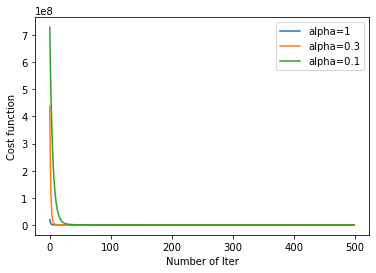

In [14]:

theta1,cost_J1=gradientDescent(X_normalized,y,[[0],[0],[0]],1)
theta2,cost_J2=gradientDescent(X_normalized,y,[[0],[0],[0]],0.3)
theta3,cost_J3=gradientDescent(X_normalized,y,[[0],[0],[0]],0.1)
# plot
plt.plot(cost_J1,label='alpha=1')
plt.plot(cost_J2,label='alpha=0.3')
plt.plot(cost_J3,label='alpha=0.1')
plt.xlabel('Number of Iter')
plt.ylabel('Cost function')
plt.legend()

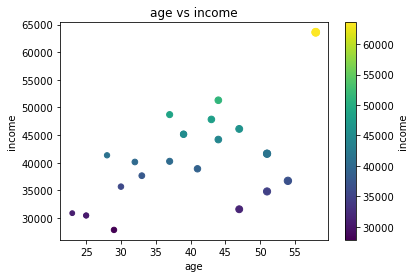

In [15]:
plt.scatter(data['age'], data['income'],
            c=data['income'],   
            s=data['age'])

plt.xlabel('age')
plt.ylabel('income')
plt.title('age vs income')

plt.colorbar(label='income')
plt.show()

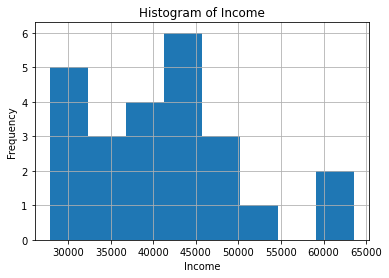

In [16]:
plt.hist(data['income'], bins=8)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Histogram of Income")
plt.grid(True)
plt.show()

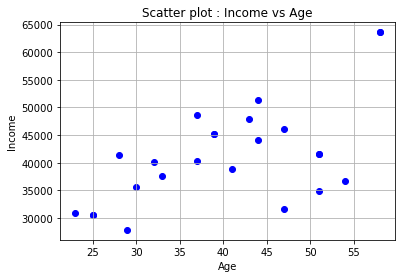

In [17]:
plt.scatter(data['age'], data['income'], color='blue')
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Scatter plot : Income vs Age")
plt.grid(True)

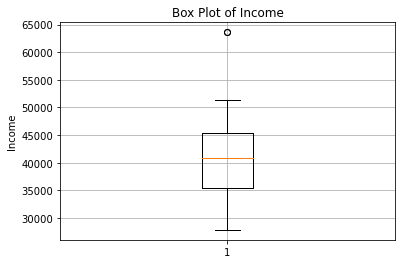

In [18]:
plt.boxplot(data['income'])
plt.ylabel("Income")
plt.title("Box Plot of Income")
plt.grid(True)
plt.show()

In [21]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data = pd.read_csv("multiple_linear_regression_dataset.csv")


X = data[['age', 'experience']]
y = data['income']


model = LinearRegression()
model.fit(X, y)


predictions = model.predict(X)


print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("\nFirst 5 predictions:")
print(predictions[:5])

Intercept: 30966.422445151875
Coefficients: [ -95.2358332  2193.27182287]

First 5 predictions:
[30778.79843795 34689.16291767 30876.88193036 38885.234897
 48803.99984611]
